## 1. Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
from pathlib import Path

from dataset import WaveformDataset
from model import Autoencoder

In [2]:
dim = 32
num_file_train = 22
loss_train = 'MAE'
loss_reco = 'MAE'
crop_min = 3500
crop_max = 6500

save_param = f'validation_latent{dim}_{loss_train}_[{crop_min},{crop_max}]_reco_{loss_reco}'

In [3]:
std_norm  = np.load('checkpoints/std_norm.npy')
time_vector = np.load('../Picosec/file/time_vector.npy')

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

In [4]:
file_list_off = sorted(Path(r'D:\DAML\SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF').glob('*.h5'))[:]

dataset_off = WaveformDataset(file_list_off, std_norm)

n_val   = int(len(dataset_off) * 0.1)
n_train = len(dataset_off) - n_val

ds_train, ds_val = random_split(dataset_off, [n_train, n_val], generator=torch.Generator().manual_seed(42))

del ds_train

Rilevati 22 file HDF5. Inizio pre-caricamento del ritaglio in RAM...
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part01.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part02.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part03.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part04.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part05.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part06.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part07.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part08.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part09.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metallic-MM-perovskite-275-470-LED-OFF_part10.h5 (40,000 tracce)
-> Caricato : SPE-Run234-metall

## 2. Model loading

In [5]:
checkpoint = torch.load(f'checkpoints/modello_migliore_latent{dim}.pt')
modello = Autoencoder(latent_dim=dim)
modello.load_state_dict(checkpoint['pesi'])
modello.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modello = modello.to(device)

print(f"Modello caricato — epoca {checkpoint['epoca']} | val_loss {checkpoint['val_loss']:.6e}")

<ipython-input-5-33efc9f34930>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'checkpoints/modello_migliore_latent{dim}.pt')


Modello caricato — epoca 59 | val_loss 6.849997e-01


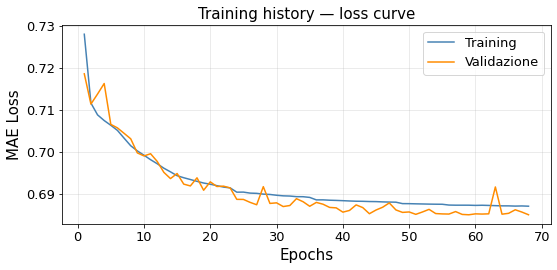

In [6]:
with open(f"checkpoints/storia_latent{dim}.json") as f:
    storia = json.load(f)

epoche = range(1, len(storia["train"]) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epoche, storia["train"], label="Training",    color="steelblue")
ax.plot(epoche, storia["val"],   label="Validazione", color="darkorange")
ax.set_xlabel("Epochs")
ax.set_ylabel(f"{loss_train} Loss")
ax.set_title("Training history — loss curve")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Storia_latent{dim}_{num_file_train}file.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [7]:
def get_reconstructions(dataset, modello, n=6, device='cuda'):
    indices = np.random.choice(len(dataset), n, replace=False)
    waveforms = torch.stack([dataset[i] for i in indices]).to(device)        # Fetch and stack them into a single batch tensor
    
    with torch.no_grad():       # No gradient tracking needed, this is inference only
        ricostruite, _ = modello(waveforms)     # Forward pass; discard the latent vector here
    
    return waveforms.cpu().numpy(), ricostruite.cpu().numpy(), indices      # Move back to CPU/numpy for plotting

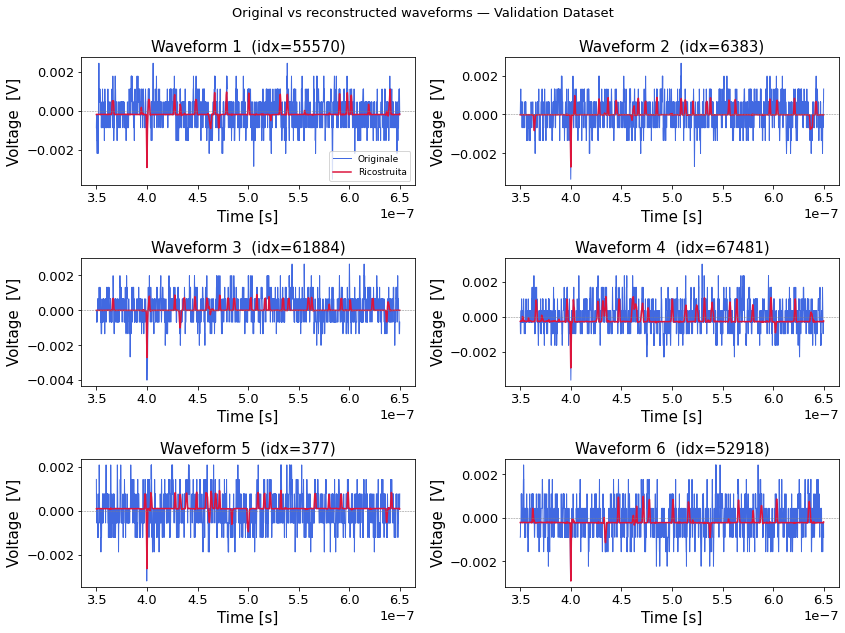

In [8]:
wf_orig_off, wf_reco_off, idx_off = get_reconstructions(ds_val,  modello, n=6, device=device)

wf_orig_volt_off = wf_orig_off * std_norm 
wf_reco_volt_off = wf_reco_off * std_norm 

fig, assi = plt.subplots(3, 2, figsize=(12, 9))
assi = assi.flatten()

for i in range(6):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig_volt_off[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco_volt_off[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage  [V]')
    ax.set_title(f'Waveform {i+1}  (idx={idx_off[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Original vs reconstructed waveforms — Validation Dataset', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 3. Reconstruction error (anomaly score)

In [9]:
def calcola_errori(modello, loader, device, std_norm, etichetta=""):
    modello.eval()
    errori = []
    n_batch = len(loader)
    std = torch.tensor(std_norm, dtype=torch.float32).to(device)
    for i, wf in enumerate(loader):
        wf = wf.to(device)
        with torch.no_grad():
            err = modello.reconstruction_error_mae(wf)
        errori.append(err.cpu().numpy())
        if (i+1) % 50 == 0 or (i+1) == n_batch:
            print(f"  {etichetta}: batch {i+1}/{n_batch}", end="\r")
    print()
    return np.concatenate(errori)

In [10]:
loader_val  = DataLoader(ds_val,  batch_size=512, shuffle=False, num_workers=0)
err_val  = calcola_errori(modello, loader_val,  device, std_norm, "LED off")
print(err_val)

  LED off: batch 170/170
[0.68613374 0.69908017 0.69167435 ... 0.7151962  0.60315174 0.6698399 ]


## 4. Anomaly score distribution

Soglia (99° pct LED off): 0.8313


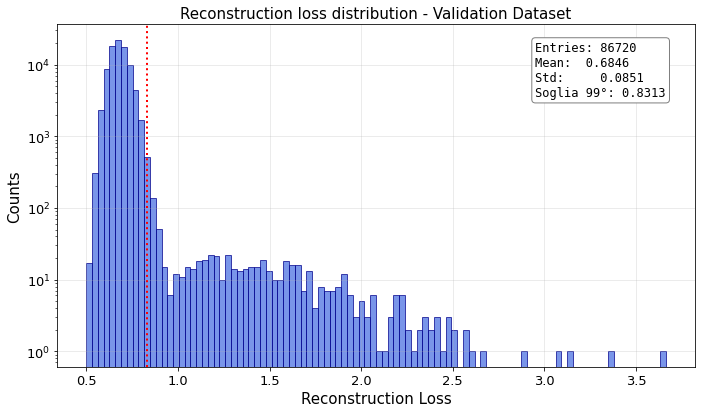

In [11]:
soglia_99 = np.percentile(err_val, 99)
print(f"Soglia (99° pct LED off): {soglia_99:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(err_val, bins=100, color='royalblue', alpha=0.7, edgecolor='darkblue')
ax.axvline(soglia_99, color='red', lw=2, ls=':')  
ax.set_xlabel("Reconstruction Loss")
ax.set_ylabel("Counts")
ax.set_title("Reconstruction loss distribution - Validation Dataset")
ax.set_yscale('log')
#ax.set_xscale('log')
ax.grid(alpha=0.3)

stats_text = (f"Entries: {len(err_val)}\n"
              f"Mean:  {err_val.mean():.4f}\n"
              f"Std:     {err_val.std():.4f}\n"
              f"Soglia 99°: {soglia_99:.4f}")

ax.text(0.75, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=1), fontfamily='monospace')


fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_errore_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

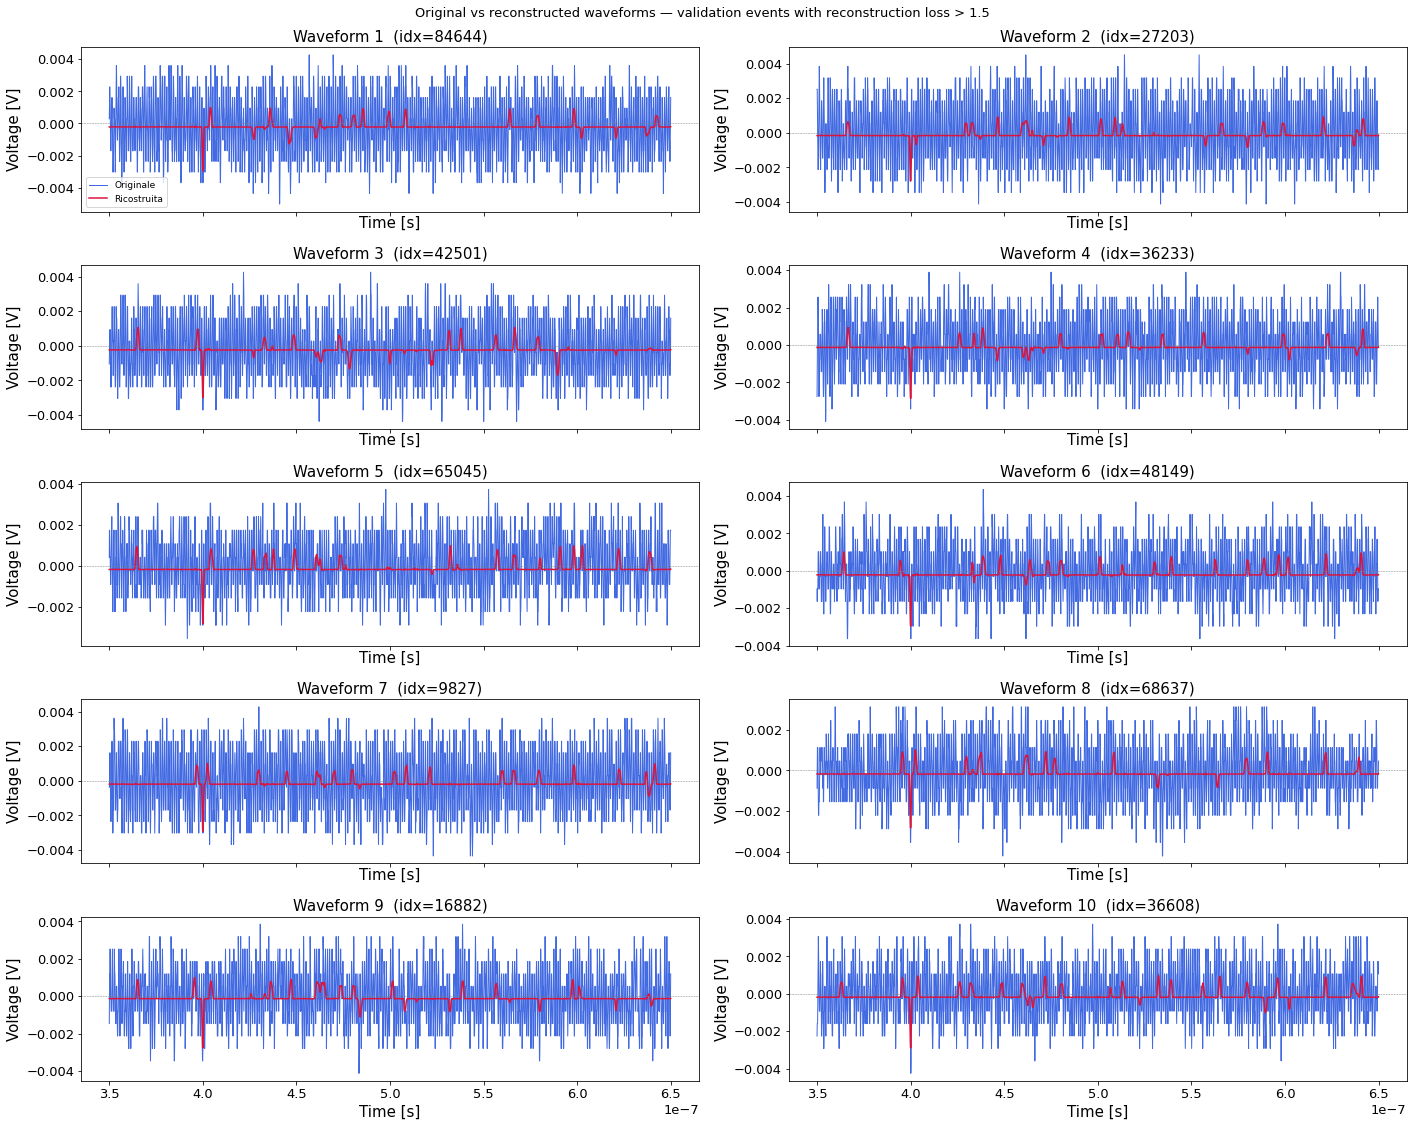

In [12]:
mask_alti = err_val > 1.5
idx_alti = np.where(mask_alti)[0] 

N_PLOT = 10
idx_plot = np.random.choice(idx_alti, min(N_PLOT, len(idx_alti)), replace=False)

waveforms = torch.stack([ds_val[i] for i in idx_plot]).to(device)

with torch.no_grad():
    ricostruite, _ = modello(waveforms)

wf_orig = waveforms.cpu().numpy()
wf_reco = ricostruite.cpu().numpy()

wf_orig = wf_orig * std_norm 
wf_reco = wf_reco * std_norm 

fig, axes = plt.subplots(5, 2, figsize=(20, 16), sharex=True)
assi = axes.flatten()

for i in range(10):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.set_title(f'Waveform {i+1}  (idx={idx_plot[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Original vs reconstructed waveforms — validation events with reconstruction loss > 1.5', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_MAE_oltre1.5_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Latent space visualization (PCA)

In [13]:
from sklearn.decomposition import PCA

def estrai_latenti(modello, loader, device):
    modello.eval()
    latenti = []
    for wf in loader:
        wf = wf.to(device)
        z = modello.encode(wf)
        latenti.append(z.detach().cpu().numpy())
    return np.concatenate(latenti)

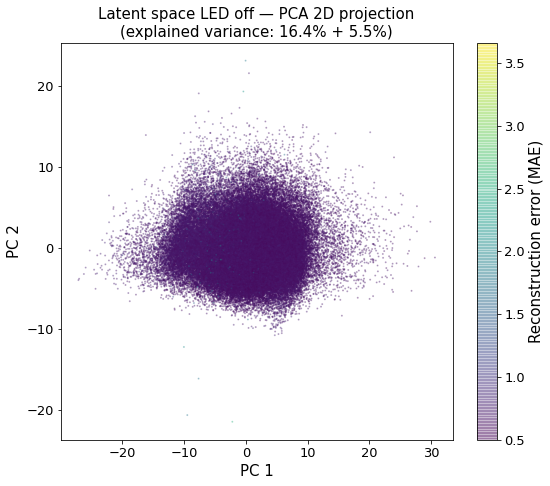

In [ ]:
N = 100_000

n_disponibili = min(N, len(ds_val))
loader_val_sub = DataLoader(torch.utils.data.Subset(ds_val, range(n_disponibili)), batch_size=512, shuffle=False)

z_segnale = estrai_latenti(modello, loader_val_sub, device)

reducer = PCA(n_components=2, random_state=42)
z_2d = reducer.fit_transform(z_segnale)

fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], s=1, alpha=0.3, c=err_val[:N], cmap='viridis')
plt.colorbar(sc, ax=ax, label='Reconstruction error (MAE)')
var = reducer.explained_variance_ratio_
ax.set_title(f'Latent space LED off — PCA 2D projection\n(explained variance: {var[0]:.1%} + {var[1]:.1%})')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/spazio_latente_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()